# Just for Scratch Work

In [21]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

par = Path().cwd().parent
print(par)
sys.path.append(str(par))

from cfg_data import AnalysisBase

cfg_file = Path.cwd().parent / "config.toml"
candidates_file = Path("../Data/Experiments/combined_candidates.csv")
volume_file = Path("../Data/volumes/M50L-18.raw")


/Users/jim/Documents/GitHub/particles


In [22]:
analysis_vol = AnalysisBase(cfg_file, vol_index=17, exp_index=0)
df_candidates = pd.read_csv(candidates_file)

Using metadata file /Users/jim/Documents/GitHub/particles/Data/volumes/M50L-06.xtekhelixct instead of /Users/jim/Documents/GitHub/particles/Data/volumes/M50L-18.xtekhelixct, exists=True


/var/folders/29/803dzgr92dx7_lk8zb5y_j7r0000gn/T/ipykernel_58977/2959725859.py:2: DtypeWarning: Columns (53,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_candidates = pd.read_csv(candidates_file)


In [41]:
def enhance(img):
    gs_landmarks = analysis_vol.grayscale_landmarks
    enhanced = (img.astype(np.float32) - gs_landmarks["air_grayvalue"]) / (
        gs_landmarks["max_grayvalue"] - gs_landmarks["air_grayvalue"]
    )
    enhanced = 255 * enhanced
    return np.clip(enhanced, 0, 255).astype(np.uint8)

l, h, w = analysis_vol.vol.shape
z_loc = 1896
y_loc = 1300
x_loc = 631
z_slice = analysis_vol.vol[z_loc, :, :]
z_baseline = np.median(analysis_vol.vol[z_loc-12: z_loc+13, :, :], axis=0)
residual = z_slice.astype(np.int16) - z_baseline.astype(np.int16)
z_slice_enh = enhance(z_slice)
z_baseline_enh = enhance(z_baseline)

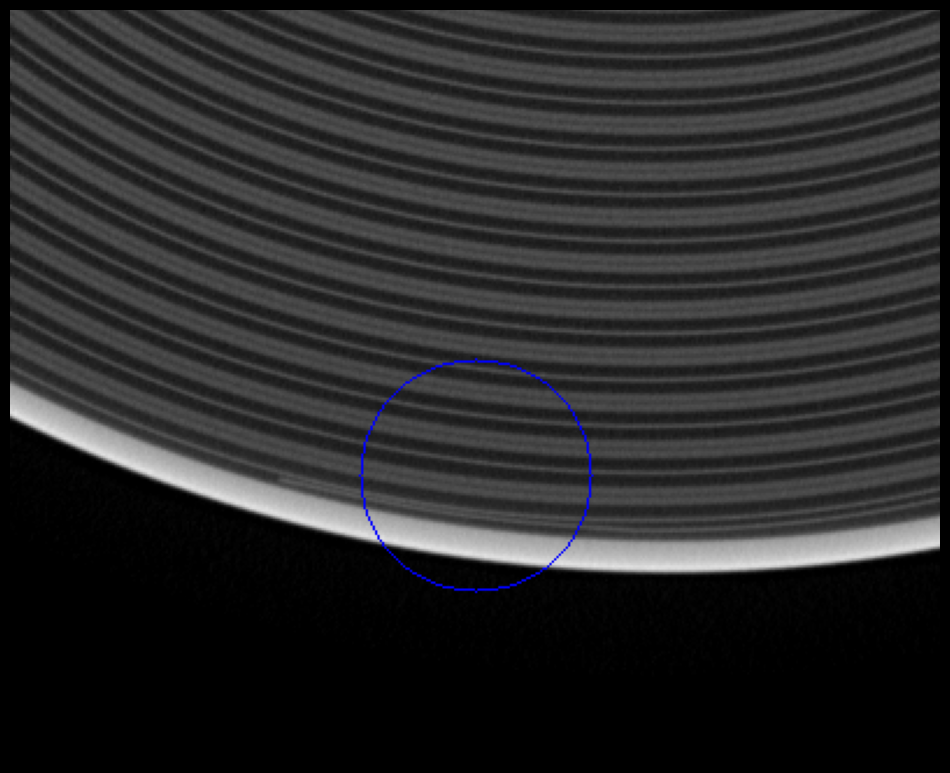

In [29]:
plt.style.use("dark_background")
tmp = cv2.cvtColor(z_baseline_enh, cv2.COLOR_GRAY2BGR)
tmp = cv2.circle(tmp, (x_loc, y_loc), 50, (0, 0, 255), 1)
pad = 200
row_slice = slice(max(0, y_loc - pad), min(h - 1, y_loc + pad))
col_slice = slice(max(0, x_loc - pad), min(w - 1, x_loc + pad))
plt.figure(figsize=(12, 12))
plt.axis("off")
plt.imshow(tmp[row_slice, col_slice])

19 0.0018654355186211143 2.8429313881623726


(np.float64(-0.5), np.float64(399.5), np.float64(323.5), np.float64(-0.5))

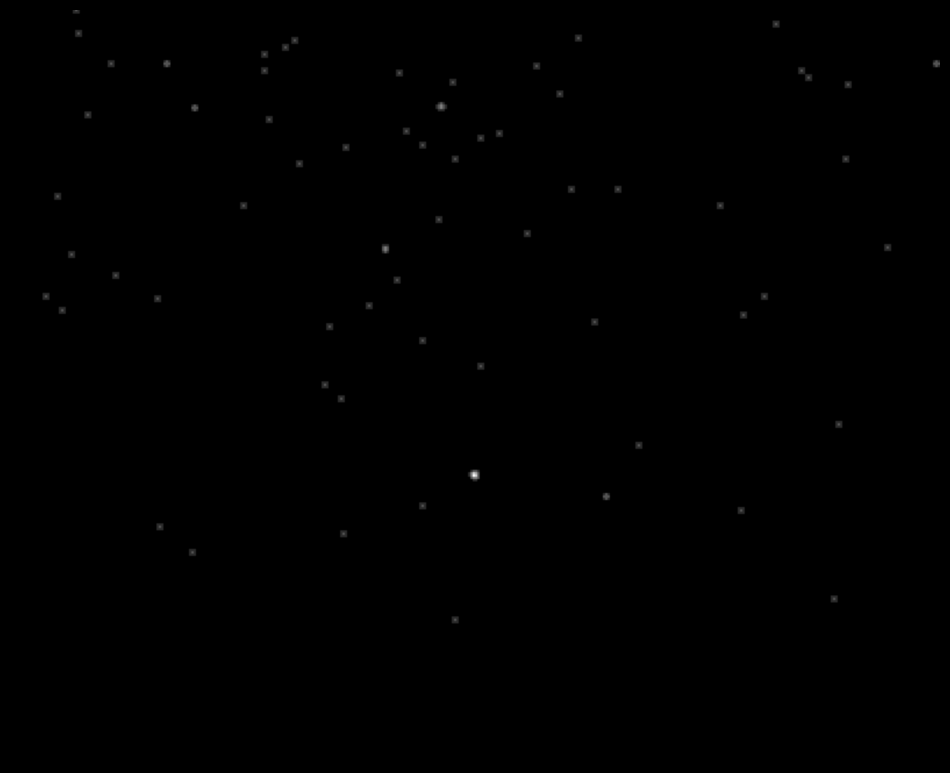

In [50]:

tmp = residual.copy()
print(tmp.max(), np.mean(tmp), np.std(tmp))
tmp[tmp < 2.84*4.2] = 0
tmp = cv2.GaussianBlur(tmp, (5, 5), 0)
plt.figure(figsize=(12, 12))
plt.imshow(tmp[row_slice, col_slice], cmap = "gray")
plt.axis('off')